# 데이터 분석 노트북 — Pipeline Server 과제

3개 파일의 데이터를 탐색하고, 노이즈 패턴을 시각화하여 정제 정책을 결정한다.

In [1]:
import json
import csv
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import seaborn as sns
from collections import Counter
from pathlib import Path

# 1) matplotlib 폰트 캐시 삭제 & 리빌드
cache_dir = Path.home() / ".matplotlib"
for f in cache_dir.glob("fontlist-*"):
    f.unlink()

# 2) NanumGothic 폰트 직접 등록
font_path = "/System/Library/AssetsV2/com_apple_MobileAsset_Font8/7a0b5c0f3c1d41c4c52a33343496c9c65ad52c50.asset/AssetData/NanumGothic.ttc"
fm.fontManager.addfont(font_path)
prop = fm.FontProperties(fname=font_path)
font_name = prop.get_name()

plt.rcParams.update({
    "font.family": font_name,
    "axes.unicode_minus": False,
})
sns.set_theme(style="whitegrid", rc={
    "font.family": font_name,
    "axes.unicode_minus": False,
})

# 데이터 로드
with open("../data/selections.json") as f:
    selections_raw = json.load(f)

odds_df = pd.read_csv("../data/odds.csv")
labels_df = pd.read_csv("../data/labels.csv")

print(f"selections: {len(selections_raw):,}건")
print(f"odds:       {len(odds_df):,}건")
print(f"labels:     {len(labels_df):,}건")

Matplotlib is building the font cache; this may take a moment.


selections: 98,776건
odds:       96,799건
labels:     322,856건


## 1. selections.json — 스키마 변형 분석

차량 수집 소프트웨어 버전에 따라 **2가지 스키마**가 혼재되어 있다.

In [16]:
# 스키마 분류
v2_sensor = [s for s in selections_raw if "sensor" in s]
v1_flat   = [s for s in selections_raw if "temperature" in s]

print(f"v2 (sensor 타입): {len(v2_sensor):,}건")
print(f"v1 (flat 타입):   {len(v1_flat):,}건")
print()

# 샘플 비교
print("=== v2 (sensor 타입) 샘플 ===")
print(json.dumps(v2_sensor[0], indent=2, ensure_ascii=False))
print()
print("=== v1 (flat 타입) 샘플 ===")
print(json.dumps(v1_flat[0], indent=2, ensure_ascii=False))

v2 (sensor 타입): 69,088건
v1 (flat 타입):   29,688건

=== v2 (sensor 타입) 샘플 ===
{
  "id": 1,
  "recordedAt": "2026-01-11T06:58:26+09:00",
  "sensor": {
    "temperature": {
      "value": 38,
      "unit": "F"
    },
    "wiper": {
      "isActive": false,
      "level": 0
    },
    "headlights": false
  },
  "sourcePath": "/data/processed/2026-01/00001.mp4"
}

=== v1 (flat 타입) 샘플 ===
{
  "id": 2,
  "recordedAt": "2026-01-01T08:31:00+09:00",
  "temperature": 19.2,
  "isWiperOn": false,
  "headlightsOn": false,
  "sourcePath": "/data/raw/00002.mp4"
}


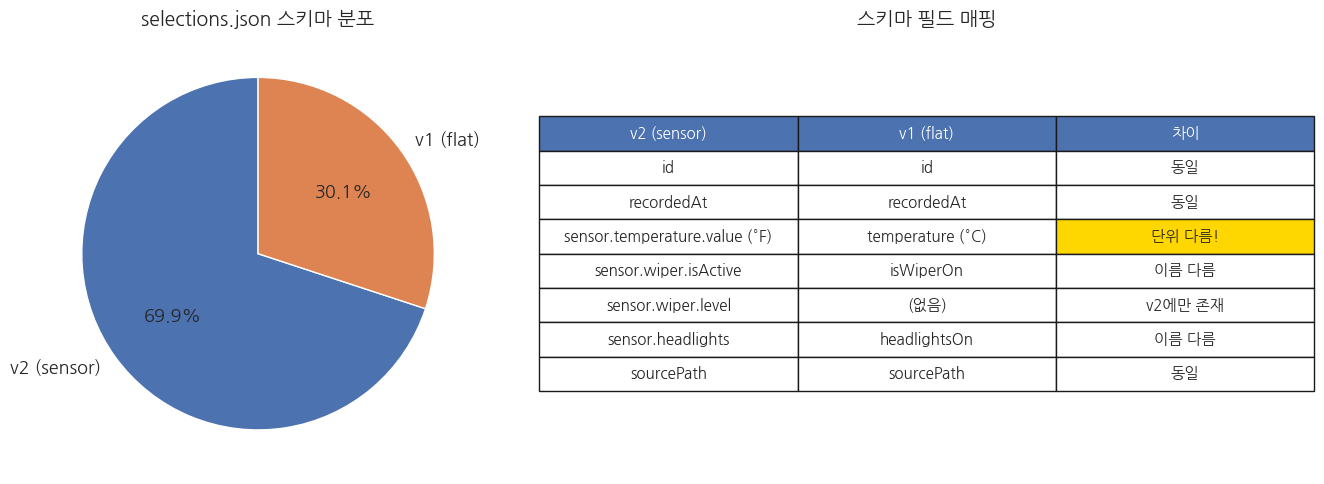

In [17]:
# 스키마 비율 시각화
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 1-1. 스키마 비율 파이 차트
schema_counts = {"v2 (sensor)": len(v2_sensor), "v1 (flat)": len(v1_flat)}
colors = ["#4C72B0", "#DD8452"]
axes[0].pie(schema_counts.values(), labels=schema_counts.keys(), autopct="%1.1f%%",
            colors=colors, startangle=90, textprops={"fontsize": 13})
axes[0].set_title("selections.json 스키마 분포", fontsize=14, fontweight="bold")

# 1-2. 두 스키마의 필드 매핑 테이블 시각화
field_map = [
    ["id", "id", "동일"],
    ["recordedAt", "recordedAt", "동일"],
    ["sensor.temperature.value (°F)", "temperature (°C)", "단위 다름!"],
    ["sensor.wiper.isActive", "isWiperOn", "이름 다름"],
    ["sensor.wiper.level", "(없음)", "v2에만 존재"],
    ["sensor.headlights", "headlightsOn", "이름 다름"],
    ["sourcePath", "sourcePath", "동일"],
]
axes[1].axis("off")
table = axes[1].table(
    cellText=field_map,
    colLabels=["v2 (sensor)", "v1 (flat)", "차이"],
    loc="center",
    cellLoc="center",
)
table.auto_set_font_size(False)
table.set_fontsize(11)
table.scale(1.2, 1.8)
# 헤더 색상
for j in range(3):
    table[0, j].set_facecolor("#4C72B0")
    table[0, j].set_text_props(color="white", fontweight="bold")
# "단위 다름!" 행 강조
table[3, 2].set_facecolor("#FFD700")
table[3, 2].set_text_props(fontweight="bold")
axes[1].set_title("스키마 필드 매핑", fontsize=14, fontweight="bold")

plt.tight_layout()
plt.show()

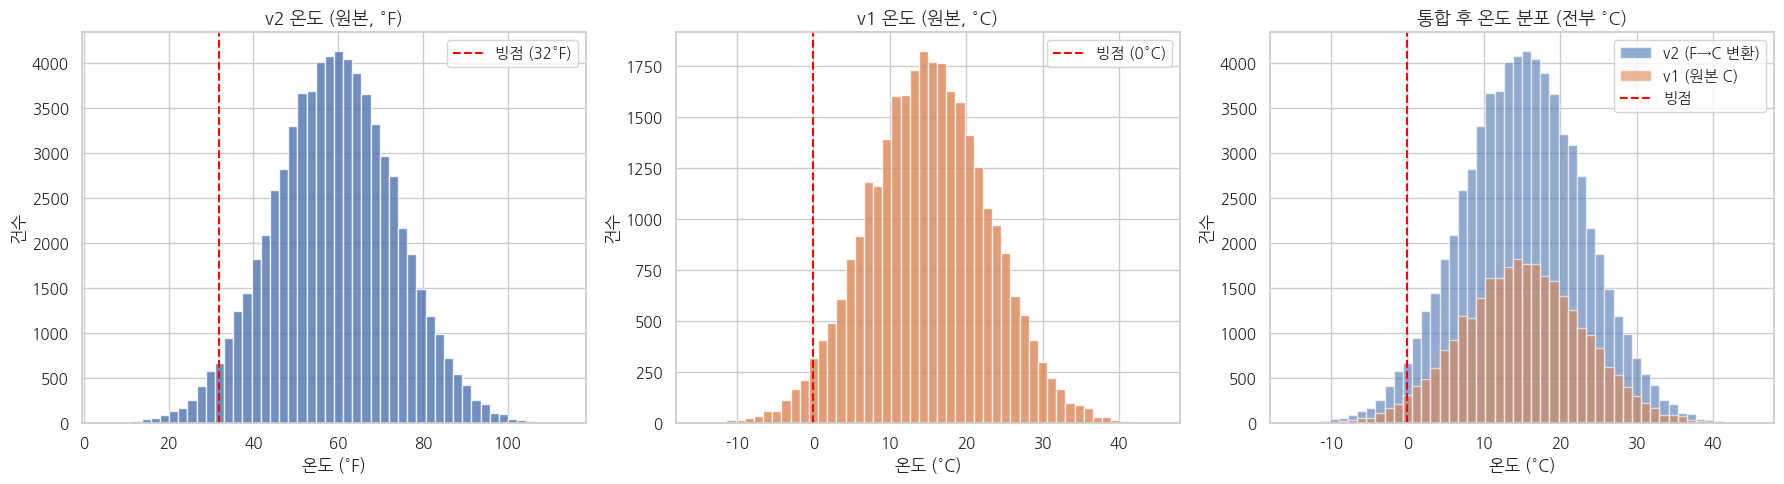

v2 화씨 범위: 5°F ~ 113°F
v2 → 섭씨 변환: -15.0°C ~ 45.0°C
v1 섭씨 범위:   -15°C ~ 45°C

→ 변환 후 두 분포가 거의 동일한 범위 → 단위 추정 정확!


In [18]:
# 온도 분포 비교 — 단위 불일치 시각화
v2_temps_f = [s["sensor"]["temperature"]["value"] for s in v2_sensor]
v1_temps_c = [s["temperature"] for s in v1_flat]

# 화씨 → 섭씨 변환한 것과 원본 비교
v2_temps_c = [(f - 32) * 5 / 9 for f in v2_temps_f]

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# 원본 v2 (화씨)
axes[0].hist(v2_temps_f, bins=50, color="#4C72B0", alpha=0.8, edgecolor="white")
axes[0].set_title("v2 온도 (원본, °F)", fontsize=13, fontweight="bold")
axes[0].set_xlabel("온도 (°F)")
axes[0].set_ylabel("건수")
axes[0].axvline(x=32, color="red", linestyle="--", label="빙점 (32°F)")
axes[0].legend()

# 원본 v1 (섭씨)
axes[1].hist(v1_temps_c, bins=50, color="#DD8452", alpha=0.8, edgecolor="white")
axes[1].set_title("v1 온도 (원본, °C)", fontsize=13, fontweight="bold")
axes[1].set_xlabel("온도 (°C)")
axes[1].set_ylabel("건수")
axes[1].axvline(x=0, color="red", linestyle="--", label="빙점 (0°C)")
axes[1].legend()

# 통합 후 (전부 섭씨)
axes[2].hist(v2_temps_c, bins=50, color="#4C72B0", alpha=0.6, label="v2 (F→C 변환)", edgecolor="white")
axes[2].hist(v1_temps_c, bins=50, color="#DD8452", alpha=0.6, label="v1 (원본 C)", edgecolor="white")
axes[2].set_title("통합 후 온도 분포 (전부 °C)", fontsize=13, fontweight="bold")
axes[2].set_xlabel("온도 (°C)")
axes[2].set_ylabel("건수")
axes[2].axvline(x=0, color="red", linestyle="--", label="빙점")
axes[2].legend()

plt.tight_layout()
plt.show()

print(f"v2 화씨 범위: {min(v2_temps_f)}°F ~ {max(v2_temps_f)}°F")
print(f"v2 → 섭씨 변환: {min(v2_temps_c):.1f}°C ~ {max(v2_temps_c):.1f}°C")
print(f"v1 섭씨 범위:   {min(v1_temps_c)}°C ~ {max(v1_temps_c)}°C")
print(f"\n→ 변환 후 두 분포가 거의 동일한 범위 → 단위 추정 정확!")

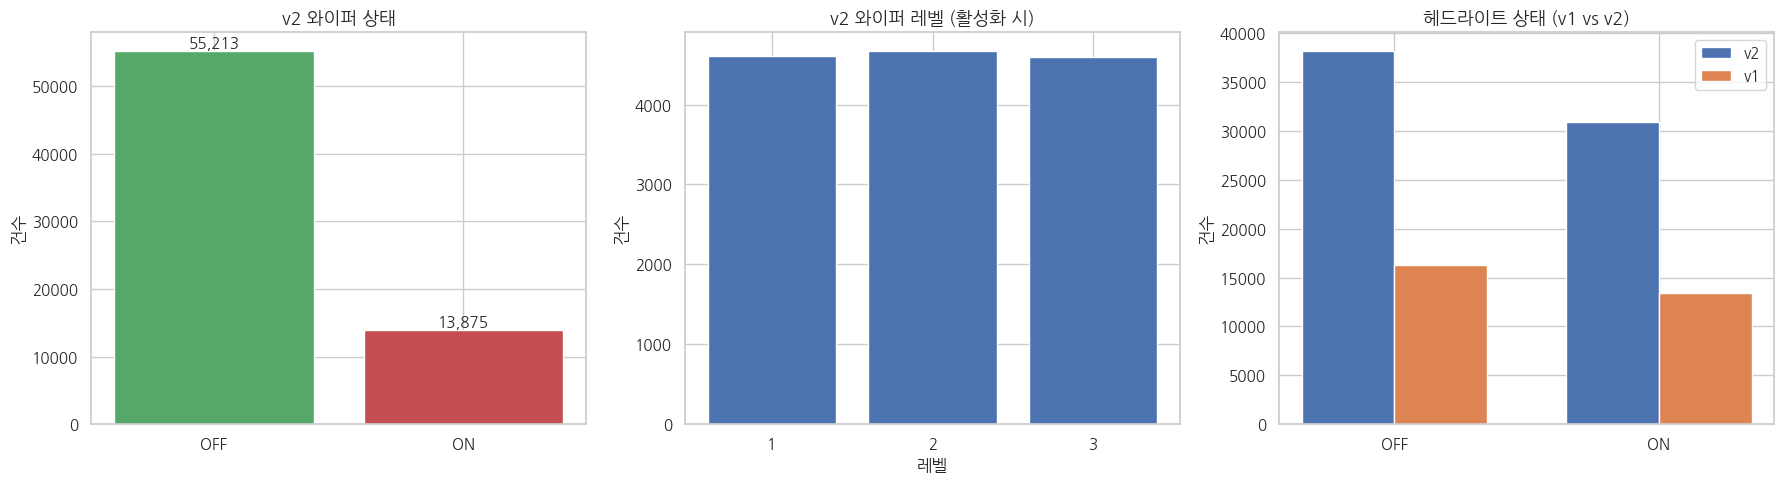

In [19]:
# 센서 데이터 분포 — 와이퍼, 헤드라이트
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# 와이퍼 활성화 상태 (v2)
wiper_active = Counter(s["sensor"]["wiper"]["isActive"] for s in v2_sensor)
axes[0].bar(["OFF", "ON"], [wiper_active[False], wiper_active[True]], color=["#55A868", "#C44E52"])
axes[0].set_title("v2 와이퍼 상태", fontsize=13, fontweight="bold")
axes[0].set_ylabel("건수")
for i, (label, val) in enumerate(zip(["OFF", "ON"], [wiper_active[False], wiper_active[True]])):
    axes[0].text(i, val + 500, f"{val:,}", ha="center", fontsize=11)

# 와이퍼 레벨 분포 (v2, 활성화된 것만)
wiper_levels = Counter(s["sensor"]["wiper"]["level"] for s in v2_sensor if s["sensor"]["wiper"]["isActive"])
levels = sorted(wiper_levels.keys())
axes[1].bar([str(l) for l in levels], [wiper_levels[l] for l in levels], color="#4C72B0")
axes[1].set_title("v2 와이퍼 레벨 (활성화 시)", fontsize=13, fontweight="bold")
axes[1].set_xlabel("레벨")
axes[1].set_ylabel("건수")

# 헤드라이트 상태 비교 (v2 vs v1)
v2_hl = Counter(s["sensor"]["headlights"] for s in v2_sensor)
v1_hl = Counter(s["headlightsOn"] for s in v1_flat)
x = [0, 1]
width = 0.35
axes[2].bar([i - width/2 for i in x], [v2_hl[False], v2_hl[True]], width, label="v2", color="#4C72B0")
axes[2].bar([i + width/2 for i in x], [v1_hl[False], v1_hl[True]], width, label="v1", color="#DD8452")
axes[2].set_xticks(x)
axes[2].set_xticklabels(["OFF", "ON"])
axes[2].set_title("헤드라이트 상태 (v1 vs v2)", fontsize=13, fontweight="bold")
axes[2].set_ylabel("건수")
axes[2].legend()

plt.tight_layout()
plt.show()

## 2. odds.csv — ODD 태깅 분석

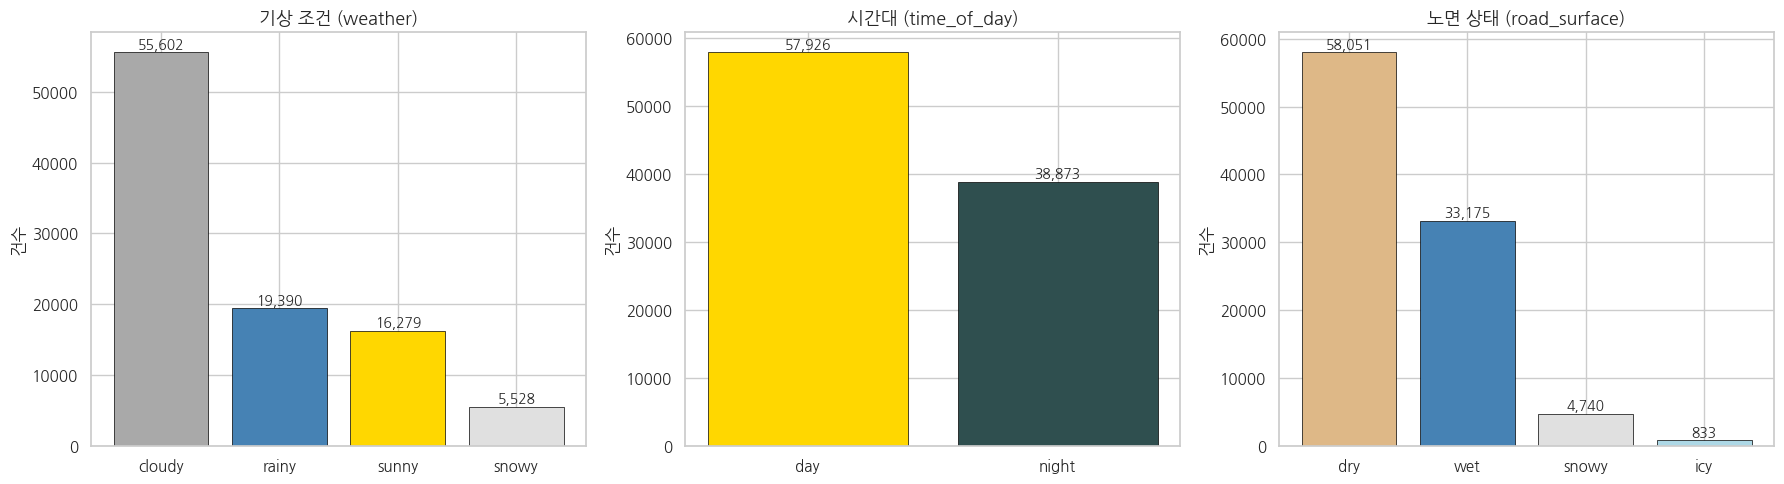

In [20]:
# ODD 태깅 분포 시각화
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# weather 분포
weather_counts = odds_df["weather"].value_counts()
colors_weather = {"sunny": "#FFD700", "cloudy": "#A9A9A9", "rainy": "#4682B4", "snowy": "#E0E0E0"}
axes[0].bar(weather_counts.index, weather_counts.values,
            color=[colors_weather[w] for w in weather_counts.index], edgecolor="black", linewidth=0.5)
axes[0].set_title("기상 조건 (weather)", fontsize=13, fontweight="bold")
axes[0].set_ylabel("건수")
for i, (w, v) in enumerate(zip(weather_counts.index, weather_counts.values)):
    axes[0].text(i, v + 500, f"{v:,}", ha="center", fontsize=10)

# time_of_day 분포
tod_counts = odds_df["time_of_day"].value_counts()
colors_tod = {"day": "#FFD700", "night": "#2F4F4F"}
axes[1].bar(tod_counts.index, tod_counts.values,
            color=[colors_tod[t] for t in tod_counts.index], edgecolor="black", linewidth=0.5)
axes[1].set_title("시간대 (time_of_day)", fontsize=13, fontweight="bold")
axes[1].set_ylabel("건수")
for i, (t, v) in enumerate(zip(tod_counts.index, tod_counts.values)):
    axes[1].text(i, v + 500, f"{v:,}", ha="center", fontsize=10)

# road_surface 분포
road_counts = odds_df["road_surface"].value_counts()
colors_road = {"dry": "#DEB887", "wet": "#4682B4", "snowy": "#E0E0E0", "icy": "#ADD8E6"}
axes[2].bar(road_counts.index, road_counts.values,
            color=[colors_road[r] for r in road_counts.index], edgecolor="black", linewidth=0.5)
axes[2].set_title("노면 상태 (road_surface)", fontsize=13, fontweight="bold")
axes[2].set_ylabel("건수")
for i, (r, v) in enumerate(zip(road_counts.index, road_counts.values)):
    axes[2].text(i, v + 500, f"{v:,}", ha="center", fontsize=10)

plt.tight_layout()
plt.show()

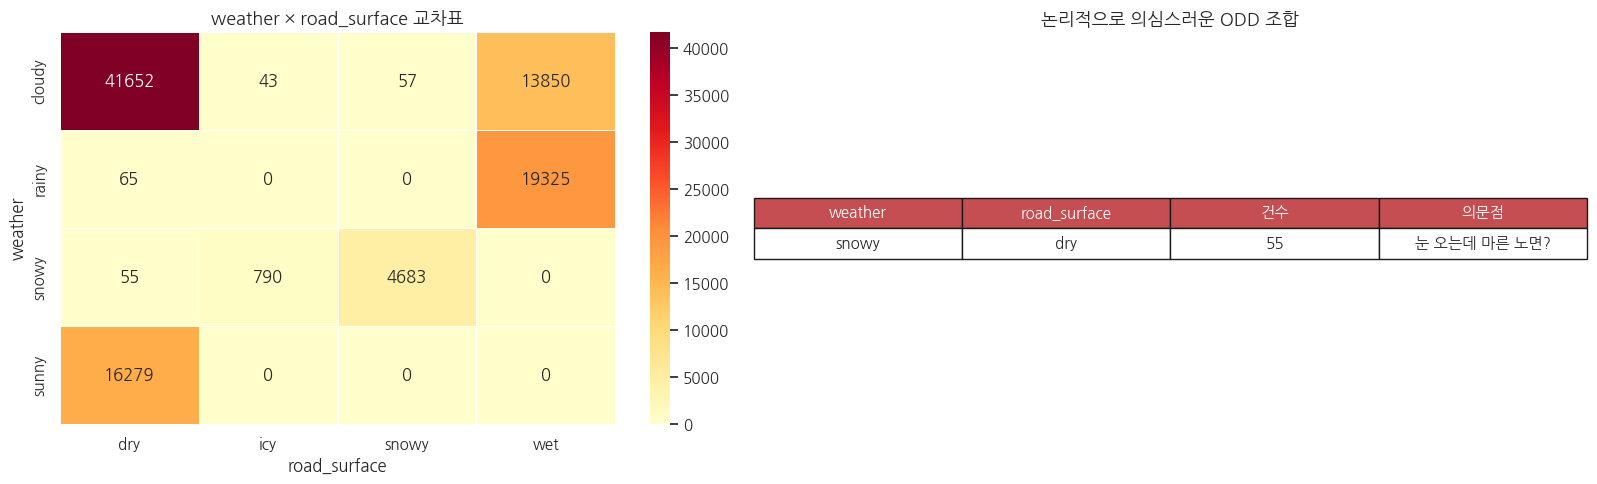

In [21]:
# ODD 조합 히트맵 — weather x road_surface
cross = pd.crosstab(odds_df["weather"], odds_df["road_surface"])
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

sns.heatmap(cross, annot=True, fmt="d", cmap="YlOrRd", ax=axes[0], linewidths=0.5)
axes[0].set_title("weather × road_surface 교차표", fontsize=13, fontweight="bold")

# 논리적 정합성 체크: sunny인데 snowy/icy, snowy인데 dry 같은 조합
# 이건 "사람이 태깅"한 결과이므로 논리적으로 이상한 조합이 존재할 수 있음
highlight_combos = {
    ("sunny", "snowy"): "맑은데 눈 덮인 노면?",
    ("sunny", "icy"): "맑은데 빙판?",
    ("snowy", "dry"): "눈 오는데 마른 노면?",
}

suspicious = []
for (w, r), desc in highlight_combos.items():
    if w in cross.index and r in cross.columns:
        count = cross.loc[w, r]
        if count > 0:
            suspicious.append([w, r, count, desc])

if suspicious:
    axes[1].axis("off")
    table = axes[1].table(
        cellText=suspicious,
        colLabels=["weather", "road_surface", "건수", "의문점"],
        loc="center", cellLoc="center"
    )
    table.auto_set_font_size(False)
    table.set_fontsize(11)
    table.scale(1.2, 1.8)
    for j in range(4):
        table[0, j].set_facecolor("#C44E52")
        table[0, j].set_text_props(color="white", fontweight="bold")
    axes[1].set_title("논리적으로 의심스러운 ODD 조합", fontsize=13, fontweight="bold")
else:
    axes[1].text(0.5, 0.5, "의심스러운 조합 없음", ha="center", fontsize=14)
    axes[1].axis("off")

plt.tight_layout()
plt.show()

In [22]:
# ODD 중복 태깅 시각화
dup_vids = odds_df[odds_df.duplicated(subset=["video_id"], keep=False)]
print(f"중복 태깅된 video_id: {dup_vids['video_id'].nunique()}개 ({len(dup_vids)}행)")
print()

# 중복 데이터 상세
dup_detail = dup_vids.sort_values(["video_id", "id"])
print(dup_detail.to_string(index=False))

# 제로패딩 video_id
zero_padded = odds_df[odds_df["video_id"].astype(str).str.match(r"^0\d+")]
print(f"\n제로패딩 video_id: {len(zero_padded)}건")
print(zero_padded.head(5).to_string(index=False))

중복 태깅된 video_id: 20개 (40행)

   id  video_id weather time_of_day road_surface
 4887      4938  cloudy         day          dry
96780      4938   rainy         day          wet
 9737      9876   sunny         day          dry
96781      9876  cloudy         day          wet
14573     14814   snowy         day          icy
96782     14814   rainy       night          wet
19405     19752   rainy       night          wet
96783     19752   snowy       night        snowy
24216     24690  cloudy         day          dry
96784     24690   snowy       night        snowy
29048     29628  cloudy       night          dry
96785     29628  cloudy       night          dry
33876     34566   rainy         day          wet
96786     34566   sunny         day          dry
38708     39504  cloudy       night          dry
96787     39504  cloudy         day          dry
43532     44442   rainy         day          wet
96788     44442   sunny         day          dry
48382     49380  cloudy         day      

## 3. labels.csv — 자동 라벨링 분석

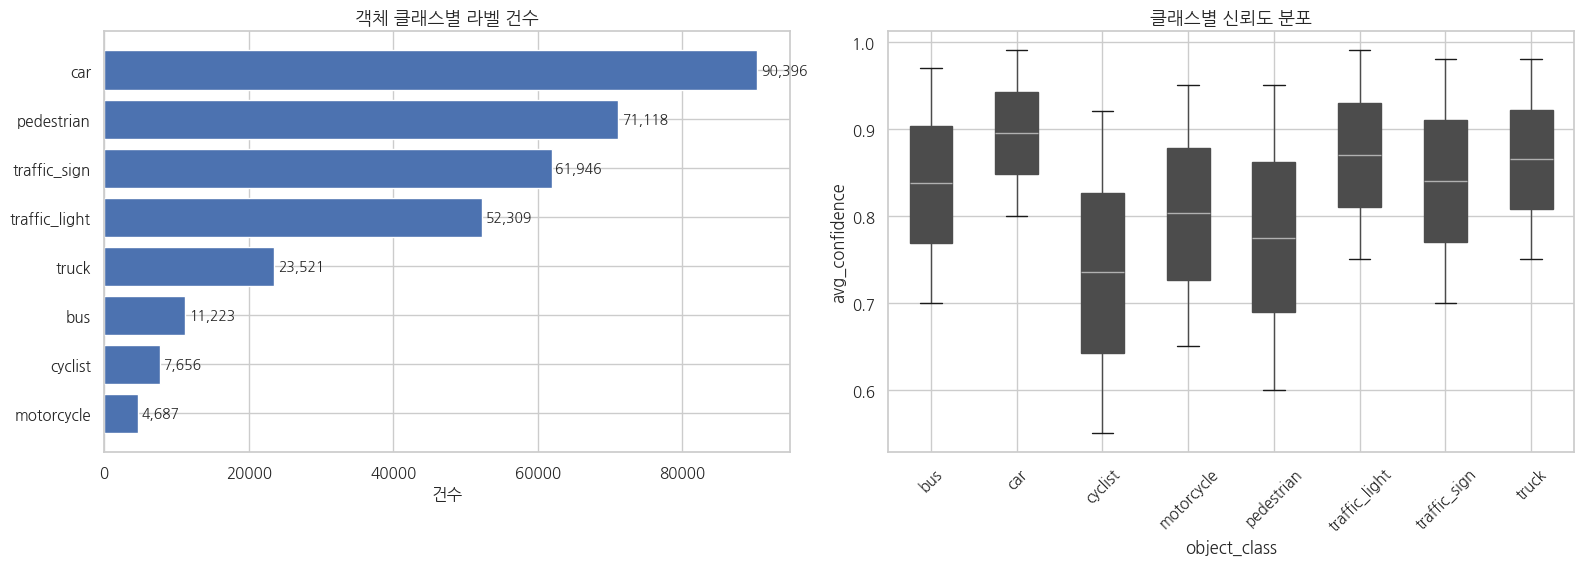

In [23]:
# object_class별 분포 + 신뢰도
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# 객체 클래스별 건수
class_counts = labels_df["object_class"].value_counts()
bars = axes[0].barh(class_counts.index[::-1], class_counts.values[::-1], color="#4C72B0", edgecolor="white")
axes[0].set_title("객체 클래스별 라벨 건수", fontsize=13, fontweight="bold")
axes[0].set_xlabel("건수")
for bar, val in zip(bars, class_counts.values[::-1]):
    axes[0].text(bar.get_width() + 500, bar.get_y() + bar.get_height()/2, f"{val:,}", va="center", fontsize=10)

# 클래스별 avg_confidence 분포 (박스플롯)
labels_df.boxplot(column="avg_confidence", by="object_class", ax=axes[1], vert=True, patch_artist=True)
axes[1].set_title("클래스별 신뢰도 분포", fontsize=13, fontweight="bold")
axes[1].set_xlabel("object_class")
axes[1].set_ylabel("avg_confidence")
plt.suptitle("")  # pandas boxplot이 자동으로 넣는 제목 제거
axes[1].tick_params(axis="x", rotation=45)

plt.tight_layout()
plt.show()

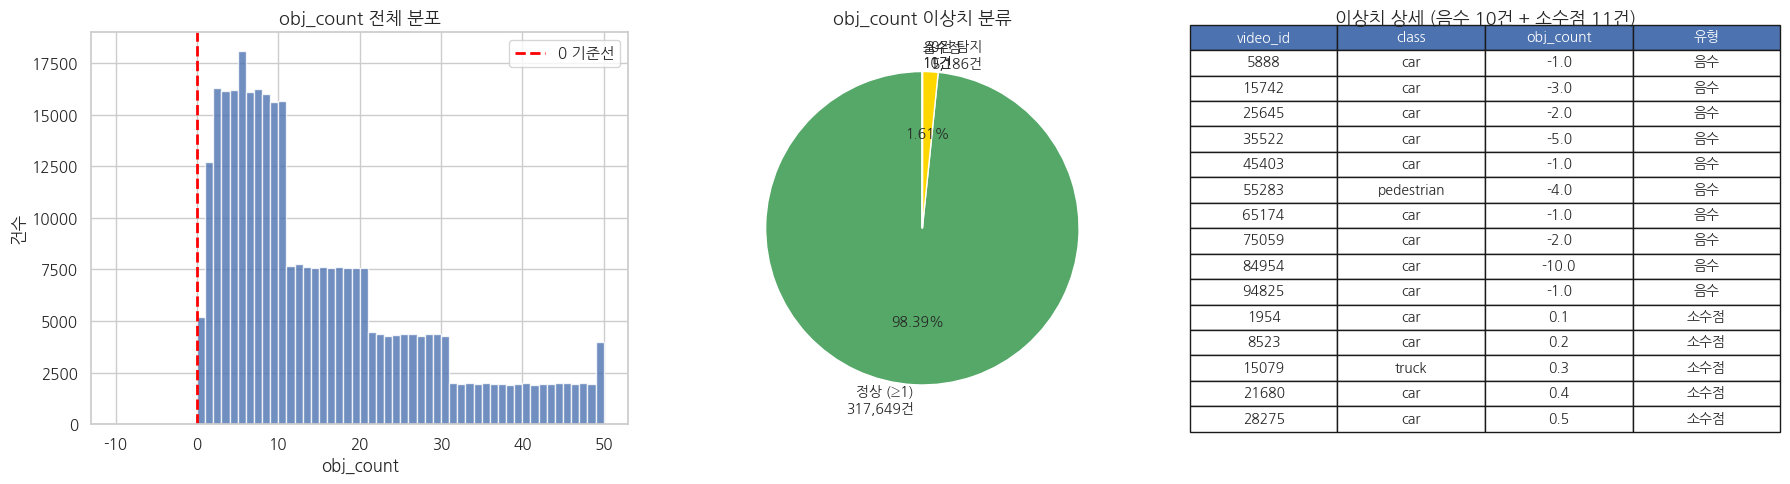

In [24]:
# obj_count 이상치 시각화
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# 전체 obj_count 분포
labels_df["obj_count_float"] = pd.to_numeric(labels_df["obj_count"], errors="coerce")
axes[0].hist(labels_df["obj_count_float"].dropna(), bins=60, color="#4C72B0", edgecolor="white", alpha=0.8)
axes[0].set_title("obj_count 전체 분포", fontsize=13, fontweight="bold")
axes[0].set_xlabel("obj_count")
axes[0].set_ylabel("건수")
axes[0].axvline(x=0, color="red", linestyle="--", linewidth=2, label="0 기준선")
axes[0].legend()

# 이상치 상세: 음수 + 소수점
negative = labels_df[labels_df["obj_count_float"] < 0]
fractional = labels_df[(labels_df["obj_count_float"] > 0) & (labels_df["obj_count_float"] < 1)]
zero = labels_df[labels_df["obj_count_float"] == 0]
normal = labels_df[labels_df["obj_count_float"] >= 1]

anomaly_data = {
    f"정상 (≥1)\n{len(normal):,}건": len(normal),
    f"0건 탐지\n{len(zero):,}건": len(zero),
    f"소수점\n{len(fractional)}건": len(fractional),
    f"음수\n{len(negative)}건": len(negative),
}
colors_anomaly = ["#55A868", "#FFD700", "#DD8452", "#C44E52"]
wedges, texts, autotexts = axes[1].pie(
    anomaly_data.values(), labels=anomaly_data.keys(),
    autopct=lambda pct: f"{pct:.2f}%" if pct > 0.01 else "",
    colors=colors_anomaly, startangle=90, textprops={"fontsize": 10}
)
axes[1].set_title("obj_count 이상치 분류", fontsize=13, fontweight="bold")

# 이상치 상세 테이블
anomaly_rows = []
for _, row in negative.iterrows():
    anomaly_rows.append([row["video_id"], row["object_class"], row["obj_count"], "음수"])
for _, row in fractional.iterrows():
    anomaly_rows.append([row["video_id"], row["object_class"], row["obj_count"], "소수점"])

axes[2].axis("off")
if anomaly_rows:
    table = axes[2].table(
        cellText=anomaly_rows[:15],  # 최대 15행
        colLabels=["video_id", "class", "obj_count", "유형"],
        loc="center", cellLoc="center"
    )
    table.auto_set_font_size(False)
    table.set_fontsize(10)
    table.scale(1.1, 1.5)
    for j in range(4):
        table[0, j].set_facecolor("#4C72B0")
        table[0, j].set_text_props(color="white", fontweight="bold")
axes[2].set_title(f"이상치 상세 (음수 {len(negative)}건 + 소수점 {len(fractional)}건)", fontsize=13, fontweight="bold")

plt.tight_layout()
plt.show()

In [25]:
# labels 중복 라벨링 시각화
label_dups = labels_df[labels_df.duplicated(subset=["video_id", "object_class"], keep=False)]
print(f"중복 라벨링: {label_dups[['video_id','object_class']].drop_duplicates().shape[0]}개 조합 ({len(label_dups)}행)")
print()
print(label_dups.sort_values(["video_id", "object_class"]).to_string(index=False))

중복 라벨링: 20개 조합 (40행)

 video_id object_class  obj_count  avg_confidence                labeled_at  obj_count_float
     4905          car       41.0        0.960000 2026-03-12T14:59:49+09:00             41.0
     4905          car        5.0        0.800000 2026-03-13T06:03:10+09:00              5.0
     9826          car       10.0        0.960154 2026-03-14T08:16:46+09:00             10.0
     9826          car       38.0        0.855800 2026-03-14T15:34:05+09:00             38.0
    14753          car       15.0        0.904600 2026-03-13T19:30:48+09:00             15.0
    14753          car       45.0        0.920000 2026-03-13T18:06:07+09:00             45.0
    19696          car       29.0        0.956000 2026-03-13T04:31:04+09:00             29.0
    19696          car       49.0        0.847640 2026-03-15T06:30:50+09:00             49.0
    24655          car       22.0        0.953000 2026-03-13T12:17:35+09:00             22.0
    24655          car       14.0        0.97787

## 4. 세 파일 간 관계 (JOIN 분석)

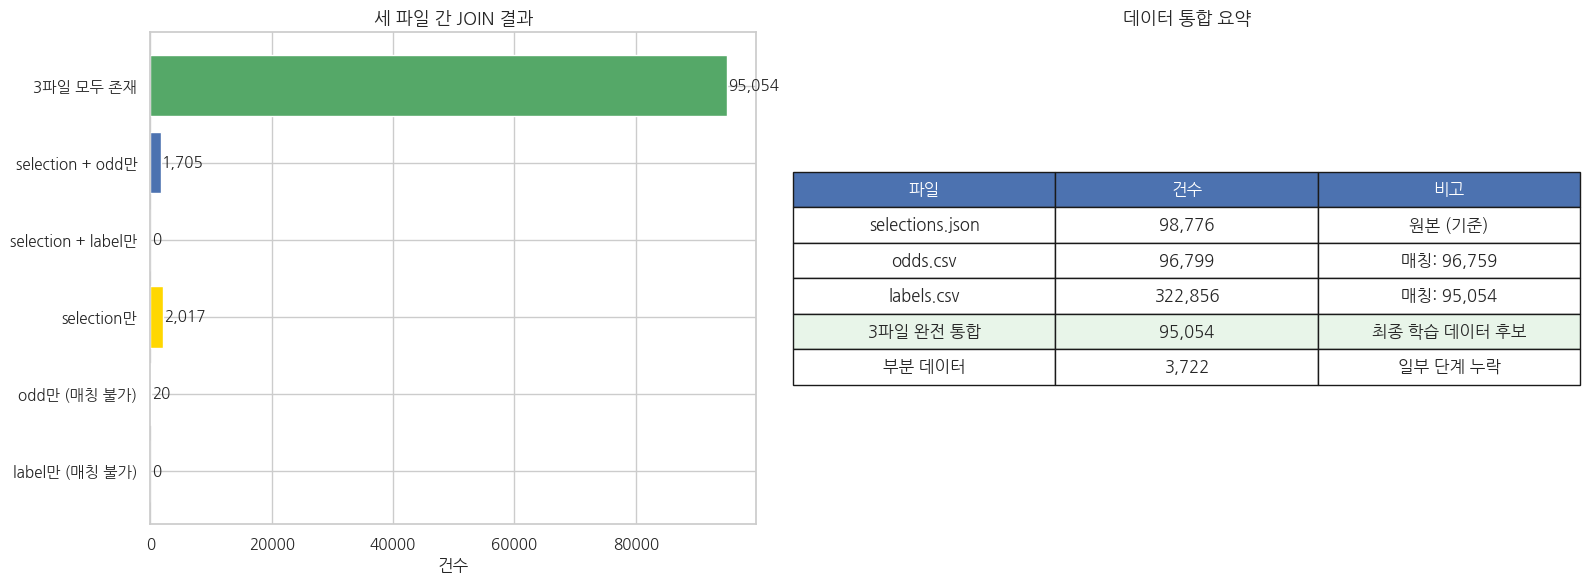

In [26]:
# 세 파일 간 ID 관계 시각화
sel_ids = set(s["id"] for s in selections_raw)
odd_vids = set(int(str(v).lstrip("0") or "0") for v in odds_df["video_id"])
label_vids = set(int(v) for v in labels_df["video_id"])

# 벤 다이어그램 수동 구현
all_three = sel_ids & odd_vids & label_vids
sel_odd_only = (sel_ids & odd_vids) - label_vids
sel_label_only = (sel_ids & label_vids) - odd_vids
sel_only = sel_ids - odd_vids - label_vids
odd_only = odd_vids - sel_ids
label_only = label_vids - sel_ids

data = {
    "3파일 모두 존재": len(all_three),
    "selection + odd만": len(sel_odd_only),
    "selection + label만": len(sel_label_only),
    "selection만": len(sel_only),
    "odd만 (매칭 불가)": len(odd_only),
    "label만 (매칭 불가)": len(label_only),
}

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# 바 차트
colors_join = ["#55A868", "#4C72B0", "#DD8452", "#FFD700", "#C44E52", "#C44E52"]
bars = axes[0].barh(list(data.keys())[::-1], list(data.values())[::-1], color=colors_join[::-1])
axes[0].set_title("세 파일 간 JOIN 결과", fontsize=13, fontweight="bold")
axes[0].set_xlabel("건수")
for bar, val in zip(bars, list(data.values())[::-1]):
    axes[0].text(bar.get_width() + 200, bar.get_y() + bar.get_height()/2, f"{val:,}", va="center", fontsize=11)

# 요약 테이블
summary = [
    ["selections.json", f"{len(sel_ids):,}", "원본 (기준)"],
    ["odds.csv", f"{len(odds_df):,}", f"매칭: {len(all_three) + len(sel_odd_only):,}"],
    ["labels.csv", f"{len(labels_df):,}", f"매칭: {len(all_three) + len(sel_label_only):,}"],
    ["3파일 완전 통합", f"{len(all_three):,}", "최종 학습 데이터 후보"],
    ["부분 데이터", f"{len(sel_odd_only) + len(sel_label_only) + len(sel_only):,}", "일부 단계 누락"],
]
axes[1].axis("off")
table = axes[1].table(cellText=summary, colLabels=["파일", "건수", "비고"], loc="center", cellLoc="center")
table.auto_set_font_size(False)
table.set_fontsize(12)
table.scale(1.3, 2.0)
for j in range(3):
    table[0, j].set_facecolor("#4C72B0")
    table[0, j].set_text_props(color="white", fontweight="bold")
table[4, 0].set_facecolor("#E8F5E9")
table[4, 1].set_facecolor("#E8F5E9")
table[4, 2].set_facecolor("#E8F5E9")
axes[1].set_title("데이터 통합 요약", fontsize=13, fontweight="bold")

plt.tight_layout()
plt.show()

## 5. 노이즈 종합 — 정제 정책 결정을 위한 요약

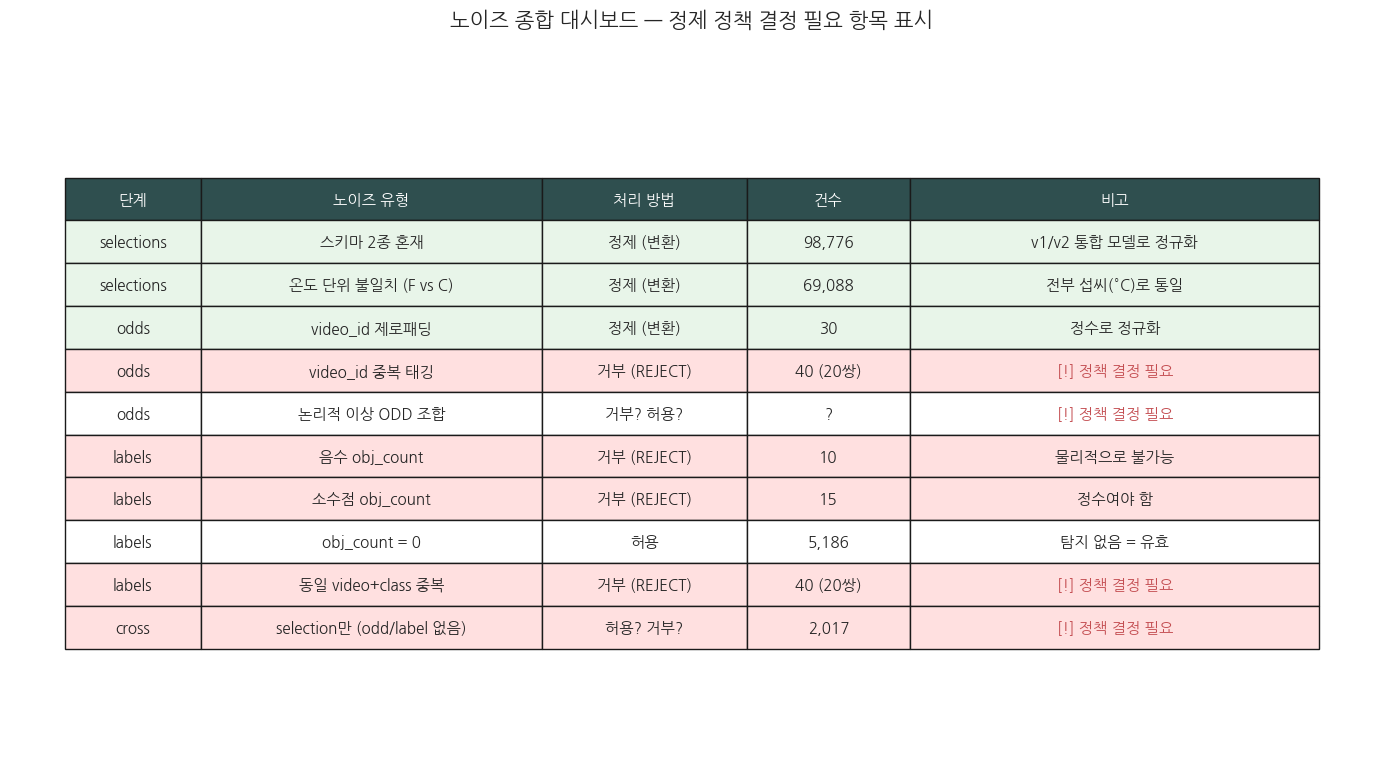


[!] 의사결정이 필요한 항목:
  1. 중복 태깅 (odds 20쌍, labels 20쌍) → 첫 번째 채택? 최신 채택? 전부 거부?
  2. 논리적 이상 ODD 조합 (sunny+snowy 등) → 거부? 허용? (사람 태깅이라 판단 불가)
  3. selection만 있는 데이터 (2,017건) → 부분 데이터로 적재? 제외?


In [2]:
# 전체 노이즈 종합 대시보드
fig, ax = plt.subplots(figsize=(14, 8))
ax.axis("off")

noise_summary = [
    ["selections", "스키마 2종 혼재", "정제 (변환)", "98,776", "v1/v2 통합 모델로 정규화"],
    ["selections", "온도 단위 불일치 (F vs C)", "정제 (변환)", "69,088", "전부 섭씨(°C)로 통일"],
    ["odds", "video_id 제로패딩", "정제 (변환)", "30", "정수로 정규화"],
    ["odds", "video_id 중복 태깅", "거부 (REJECT)", "40 (20쌍)", "[!] 정책 결정 필요"],
    ["odds", "논리적 이상 ODD 조합", "거부? 허용?", "?", "[!] 정책 결정 필요"],
    ["labels", "음수 obj_count", "거부 (REJECT)", "10", "물리적으로 불가능"],
    ["labels", "소수점 obj_count", "거부 (REJECT)", "15", "정수여야 함"],
    ["labels", "obj_count = 0", "허용", "5,186", "탐지 없음 = 유효"],
    ["labels", "동일 video+class 중복", "거부 (REJECT)", "40 (20쌍)", "[!] 정책 결정 필요"],
    ["cross", "selection만 (odd/label 없음)", "허용? 거부?", "2,017", "[!] 정책 결정 필요"],
]

table = ax.table(
    cellText=noise_summary,
    colLabels=["단계", "노이즈 유형", "처리 방법", "건수", "비고"],
    loc="center", cellLoc="center",
    colWidths=[0.1, 0.25, 0.15, 0.12, 0.3]
)
table.auto_set_font_size(False)
table.set_fontsize(11)
table.scale(1.0, 2.2)

# 헤더 스타일
for j in range(5):
    table[0, j].set_facecolor("#2F4F4F")
    table[0, j].set_text_props(color="white", fontweight="bold")

# 거부 행 강조
for i in [4, 6, 7, 9, 10]:
    for j in range(5):
        table[i, j].set_facecolor("#FFE0E0")

# 정제 행
for i in [1, 2, 3]:
    for j in range(5):
        table[i, j].set_facecolor("#E8F5E9")

# 의사결정 필요 행
for i in [4, 5, 9, 10]:
    table[i, 4].set_text_props(fontweight="bold", color="#C44E52")

ax.set_title("노이즈 종합 대시보드 — 정제 정책 결정 필요 항목 표시", fontsize=15, fontweight="bold", pad=20)
plt.tight_layout()
plt.show()

print("\n[!] 의사결정이 필요한 항목:")
print("  1. 중복 태깅 (odds 20쌍, labels 20쌍) → 첫 번째 채택? 최신 채택? 전부 거부?")
print("  2. 논리적 이상 ODD 조합 (sunny+snowy 등) → 거부? 허용? (사람 태깅이라 판단 불가)")
print("  3. selection만 있는 데이터 (2,017건) → 부분 데이터로 적재? 제외?")